**Importing Required Libraries**

In this step, the necessary Python libraries are imported for data manipulation, preprocessing, feature extraction, machine learning model training, and performance evaluation. Pandas and NumPy are used for handling datasets and numerical operations. NLTK is used for stopword removal during preprocessing. Scikit-learn libraries are used for TF-IDF vectorization, model training, and evaluation metrics.

In [1]:
# ==============================
# IMPORT REQUIRED LIBRARIES
# ==============================

# Data Handling Libraries
import pandas as pd
import numpy as np

# Regular Expressions
import re

# Natural Language Toolkit
import nltk
from nltk.corpus import stopwords

# Machine Learning Libraries
from sklearn.model_selection import train_test_split

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Classification Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Download Stopwords
nltk.download('stopwords')

print("Libraries Imported Successfully")

Libraries Imported Successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Downloading Dataset from Kaggle**

The dataset used in this project is collected directly from Kaggle using Kaggle API integration in Google Colab. The dataset contains fake and genuine news articles in CSV format. Authentication is performed using the Kaggle API token.

In [2]:
# ==============================
# INSTALL KAGGLE
# ==============================

!pip install kaggle

In [4]:
# ==============================
# CONFIGURE KAGGLE API TOKEN
# ==============================

!mkdir -p ~/.kaggle

# Replace YOUR_TOKEN with actual Kaggle token
!echo "kaggle api" > ~/.kaggle/access_token

!chmod 600 ~/.kaggle/access_token

print("Kaggle API Configured")

Kaggle API Configured


In [5]:
# ==============================
# DOWNLOAD DATASET
# ==============================

!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset

print("Dataset Downloaded Successfully")

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
100% 41.0M/41.0M [00:02<00:00, 18.0MB/s]

Dataset Downloaded Successfully


In [7]:
# ==============================
# UNZIP DATASET
# ==============================

!unzip fake-and-real-news-dataset.zip

print("Dataset Extracted Successfully")

Archive:  fake-and-real-news-dataset.zip
replace Fake.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Fake.csv                
replace True.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: True.csv                
Dataset Extracted Successfully


**Loading the Dataset**

After downloading the dataset, the fake and real news datasets are loaded into Pandas DataFrames. The dataset is then inspected to understand its structure and contents.

In [8]:
# ==============================
# LOAD DATASET
# ==============================

fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

print("Fake News Dataset Shape:", fake.shape)
print("Real News Dataset Shape:", real.shape)

Fake News Dataset Shape: (23481, 4)
Real News Dataset Shape: (21417, 4)


In [9]:
# ==============================
# DISPLAY SAMPLE DATA
# ==============================

print("\nFake News Sample:\n")
print(fake.head())

print("\nReal News Sample:\n")
print(real.head())


Fake News Sample:

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  

Real News Sample:

                                               title  \
0  As U.S. budget fight looms, Republicans f

**Assigning Labels and Combining the Dataset**

Since the project involves binary classification, labels are assigned to both datasets. Fake news articles are marked as 0, while genuine news articles are marked as 1. After labeling, both datasets are merged into a single dataframe for further processing.

In [10]:
# ==========================================
# ADD LABELS TO BOTH DATASETS
# ==========================================

fake["label"] = 0
real["label"] = 1

print("Labels assigned successfully.")

Labels assigned successfully.


In [11]:
# ==========================================
# MERGE FAKE AND REAL NEWS DATASETS
# ==========================================

data = pd.concat([fake, real], ignore_index=True)

print("Datasets merged successfully.")
print("Combined Dataset Shape:", data.shape)

Datasets merged successfully.
Combined Dataset Shape: (44898, 5)


In [12]:
# ==========================================
# KEEP ONLY REQUIRED COLUMNS
# ==========================================

data = data[["text", "label"]]

print(data.head())

                                                text  label
0  Donald Trump just couldn t wish all Americans ...      0
1  House Intelligence Committee Chairman Devin Nu...      0
2  On Friday, it was revealed that former Milwauk...      0
3  On Christmas day, Donald Trump announced that ...      0
4  Pope Francis used his annual Christmas Day mes...      0


During initial inspection of the dataset, it was observed that many genuine news articles contained publisher identifiers such as “Reuters” along with location metadata at the beginning of the article text. These patterns can introduce data leakage because the model may learn publisher-specific information instead of actual linguistic characteristics of misinformation.

To reduce this issue, a custom regular expression-based cleaning step was introduced before preprocessing. This helps improve the reliability and interpretability of the classification process by preventing the classifier from depending on source identifiers. Data leakage is a known issue in machine learning systems and can lead to unrealistically high model accuracy if not handled properly.

In [13]:
# ==========================================
# CHECK FOR REUTERS PATTERNS
# ==========================================

# Display first few real news articles
for i in range(3):

    print(f"\nArticle {i+1}:\n")

    print(real["text"].iloc[i][:500])

    print("\n" + "="*80)


Article 1:

WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they retur


Article 2:

WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after President Donald Trump’s administration decided not to appeal rulings that blocked his transgender ban. Two federal appeals courts, one in Washington and one in Virginia, last week rejected the administration’s request to put on hold orders by lower court judges requiring the mil

In [16]:
# ==========================================
# REMOVE DATA LEAKAGE PATTERNS
# ==========================================

def remove_leakage(text):

    # Remove location + Reuters patterns
    text = re.sub(r'^[A-Z\s\.,\-]+\s*\(Reuters\)\s*-\s*', '', text)

    # Remove standalone Reuters mentions
    text = re.sub(r'Reuters', '', text)

    return text

In [17]:
# ==========================================
# APPLY LEAKAGE REMOVAL
# ==========================================

fake["text"] = fake["text"].apply(remove_leakage)

real["text"] = real["text"].apply(remove_leakage)

print("Leakage patterns removed successfully.")

Leakage patterns removed successfully.


In [18]:
# ==========================================
# VERIFY CLEANED ARTICLES
# ==========================================

for i in range(3):

    print(f"\nCleaned Article {i+1}:\n")

    print(real["text"].iloc[i][:500])

    print("\n" + "="*80)


Cleaned Article 1:

The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on 


Cleaned Article 2:

Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after President Donald Trump’s administration decided not to appeal rulings that blocked his transgender ban. Two federal appeals courts, one in Washington and one in Virginia, last week rejected the administration’s request to put on hold orders by lower court judges requiring the military t

After removing potential leakage patterns, additional NLP preprocessing techniques were applied to normalize the textual data. The objective of preprocessing was to reduce noise, standardize article content, and improve feature extraction quality.

The preprocessing pipeline included:

converting text to lowercase
removing punctuation and numerical values
tokenization
stopword removal

Unlike many basic implementations, preprocessing was applied after leakage removal to ensure that publisher specific patterns were eliminated before feature extraction.

In [19]:
# ==========================================
# LOAD ENGLISH STOPWORDS
# ==========================================

stop_words = set(stopwords.words('english'))

print("Stopwords loaded successfully.")

Stopwords loaded successfully.


In [108]:
# ==========================================
# ADVANCED TEXT PREPROCESSING
# ==========================================

def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Rejoin cleaned words
    cleaned_text = " ".join(words)

    return cleaned_text

In [23]:
# ==========================================
# APPLY PREPROCESSING
# ==========================================

fake["clean_text"] = fake["text"].apply(preprocess_text)

real["clean_text"] = real["text"].apply(preprocess_text)

print("Advanced preprocessing completed.")

Advanced preprocessing completed.


In [24]:
# ==========================================
# DISPLAY PREPROCESSED ARTICLES
# ==========================================

print("\nFAKE NEWS SAMPLE:\n")
print(fake["clean_text"].iloc[0][:700])

print("\n" + "="*100)

print("\nREAL NEWS SAMPLE:\n")
print(real["clean_text"].iloc[0][:700])


FAKE NEWS SAMPLE:

donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news media happy healthy new year president angry pants tweeted great year america country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news media happy healthy new year great year america donald j trump realdonaldtrump december trump tweet went welll expectwhat kind president sends new year greeting like despicable petty infantile gibberish trump lack decency even allow rise gutter long enough wish am


REAL NEWS SAMPLE:

head conservative republican faction us congress voted month huge expansion national debt pay tax cuts called fiscal conservative sunday urged budget restraint keeping sharp pivot way among republicans us representative mark meadows speaking cbs face nation 

In addition to traditional TF-IDF textual features, stylometric and linguistic features were extracted from the news articles. These features capture writing style characteristics that are commonly associated with misinformation and sensational content.

The purpose of stylometric feature engineering is to improve the model’s ability to identify suspicious linguistic patterns beyond simple word frequency analysis.

The following features were extracted:

article length
exclamation mark frequency
uppercase character ratio
lexical diversity
subjectivity score

These features were later combined with TF-IDF vectors to form a hybrid feature representation.

In [27]:
# ==========================================
# INSTALL TEXTBLOB
# ==========================================

!pip install textblob

In [28]:
# ==========================================
# IMPORT LIBRARIES FOR FEATURE ENGINEERING
# ==========================================

from textblob import TextBlob

print("Libraries imported successfully.")

Libraries imported successfully.


In [30]:
# ==========================================
# STYLOMETRIC FEATURE EXTRACTION
# ==========================================

def extract_features(text):

    # Total length of article
    article_length = len(text)

    # Count exclamation marks
    exclamation_count = text.count("!")

    # Uppercase ratio
    uppercase_ratio = sum(1 for char in text if char.isupper()) / (len(text) + 1)

    # Tokenize words
    words = text.split()

    # Lexical diversity
    lexical_diversity = len(set(words)) / (len(words) + 1)

    # Subjectivity score
    subjectivity = TextBlob(text).sentiment.subjectivity

    return pd.Series([
        article_length,
        exclamation_count,
        uppercase_ratio,
        lexical_diversity,
        subjectivity
    ])


In [31]:
# ==========================================
# APPLY FEATURE EXTRACTION
# ==========================================

feature_columns = [
    "article_length",
    "exclamation_count",
    "uppercase_ratio",
    "lexical_diversity",
    "subjectivity"
]

fake[feature_columns] = fake["text"].apply(extract_features)

real[feature_columns] = real["text"].apply(extract_features)

print("Stylometric features extracted successfully.")

Stylometric features extracted successfully.


In [32]:
# ==========================================
# DISPLAY EXTRACTED FEATURES
# ==========================================

print("\nFAKE NEWS FEATURES:\n")

print(fake[feature_columns].head())

print("\n" + "="*100)

print("\nREAL NEWS FEATURES:\n")

print(real[feature_columns].head())


FAKE NEWS FEATURES:

   article_length  exclamation_count  uppercase_ratio  lexical_diversity  \
0          2893.0                6.0         0.047685           0.554435   
1          1898.0                0.0         0.046340           0.663399   
2          3597.0                2.0         0.085603           0.574871   
3          2774.0                0.0         0.044324           0.595506   
4          2346.0                0.0         0.026843           0.565321   

   subjectivity  
0      0.599895  
1      0.334098  
2      0.541969  
3      0.394086  
4      0.495222  


REAL NEWS FEATURES:

   article_length  exclamation_count  uppercase_ratio  lexical_diversity  \
0          4636.0                0.0         0.031055           0.560910   
1          4054.0                0.0         0.026634           0.540193   
2          2766.0                0.0         0.038309           0.553846   
3          2431.0                0.0         0.040296           0.621984   
4         

**Combining Datasets and Preparing Hybrid Architecture**

After stylometric feature extraction, the fake and genuine news datasets were merged into a unified hybrid dataset. In addition to cleaned textual content, the dataset now contained linguistic and behavioral indicators such as lexical diversity, punctuation usage, article length, and subjectivity score.

These features were preserved separately so that they could later be combined with TF-IDF vectors to form a hybrid feature representation for classification.

In [33]:
# ==========================================
# MERGE PROCESSED DATASETS
# ==========================================

data = pd.concat([fake, real], ignore_index=True)

print("Datasets merged successfully.")

print("\nFinal Dataset Shape:")
print(data.shape)

Datasets merged successfully.

Final Dataset Shape:
(44898, 11)


In [34]:
# ==========================================
# DISPLAY DATASET COLUMNS
# ==========================================

print("\nAvailable Columns:\n")

print(data.columns)


Available Columns:

Index(['title', 'text', 'subject', 'date', 'label', 'clean_text',
       'article_length', 'exclamation_count', 'uppercase_ratio',
       'lexical_diversity', 'subjectivity'],
      dtype='object')


In [35]:
# ==========================================
# PREPARE INPUT FEATURES AND LABELS
# ==========================================

X_text = data["clean_text"]

y = data["label"]

print("Feature and label separation completed.")

Feature and label separation completed.


In [36]:
# ==========================================
# TRAIN-TEST SPLIT
# ==========================================

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 35918
Testing samples: 8980


To convert textual data into numerical format, TF-IDF vectorization was applied to the cleaned news articles. TF-IDF assigns importance weights to words based on their frequency within individual documents and across the dataset.

In addition to textual TF-IDF vectors, stylometric and linguistic credibility indicators were included to construct a hybrid feature representation. This hybrid architecture enables the classifier to analyze both semantic content and behavioral writing patterns.

Two experimental configurations were prepared:

baseline TF-IDF model
hybrid TF-IDF + stylometric feature model

In [37]:
# ==========================================
# IMPORT SPARSE MATRIX UTILITIES
# ==========================================

from scipy.sparse import hstack

print("Sparse matrix utilities imported.")

Sparse matrix utilities imported.


In [38]:
# ==========================================
# TF-IDF VECTORIZATION
# ==========================================

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF vectorization completed.")

TF-IDF vectorization completed.


In [39]:
# ==========================================
# DISPLAY TF-IDF MATRIX SHAPE
# ==========================================

print("Training TF-IDF Shape:", X_train_tfidf.shape)

print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (35918, 5000)
Testing TF-IDF Shape: (8980, 5000)


In [41]:
# ==========================================
# PREPARE STYLOMETRIC FEATURES
# ==========================================

stylometric_features = [
    "article_length",
    "exclamation_count",
    "uppercase_ratio",
    "lexical_diversity",
    "subjectivity"
]

X_stylo = data[stylometric_features]

In [43]:
# ==========================================
# SPLIT STYLOMETRIC FEATURES CORRECTLY
# ==========================================

X_train_stylo = X_stylo.iloc[X_train_text.index]

X_test_stylo = X_stylo.iloc[X_test_text.index]

print("Stylometric features aligned successfully.")

Stylometric features aligned successfully.


In [44]:
# ==========================================
# CREATE HYBRID FEATURE MATRIX
# ==========================================

X_train_hybrid = hstack([
    X_train_tfidf,
    X_train_stylo.values
])

X_test_hybrid = hstack([
    X_test_tfidf,
    X_test_stylo.values
])

print("Hybrid feature matrix created successfully.")

Hybrid feature matrix created successfully.


In [45]:
# ==========================================
# DISPLAY HYBRID MATRIX SHAPE
# ==========================================

print("Hybrid Training Shape:", X_train_hybrid.shape)

print("Hybrid Testing Shape:", X_test_hybrid.shape)

Hybrid Training Shape: (35918, 5005)
Hybrid Testing Shape: (8980, 5005)


**Baseline Model Training (TF-IDF Only)**

To establish a baseline performance benchmark, multiple machine learning classifiers were first trained using only TF-IDF textual features. The objective of the baseline experiment was to evaluate the effectiveness of semantic textual representations without stylometric enhancement.

Three classifiers were selected:

Naive Bayes
Logistic Regression
Linear Support Vector Machine (SVM)

These algorithms are commonly used in NLP classification tasks because of their efficiency with sparse TF-IDF matrices. Sparse TF-IDF matrices are widely used in text classification because they efficiently represent high-dimensional textual features while storing mostly non zero values.

In [46]:
# ==========================================
# IMPORT EVALUATION METRICS
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Evaluation metrics imported.")

Evaluation metrics imported.


In [47]:
# ==========================================
# NAIVE BAYES BASELINE MODEL
# ==========================================

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9299554565701559


In [48]:
# ==========================================
# NAIVE BAYES CLASSIFICATION REPORT
# ==========================================

print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4733
           1       0.93      0.92      0.93      4247

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



In [49]:
# ==========================================
# LOGISTIC REGRESSION BASELINE MODEL
# ==========================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9798440979955456


In [50]:
# ==========================================
# LOGISTIC REGRESSION REPORT
# ==========================================

print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4733
           1       0.98      0.98      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [51]:
# ==========================================
# LINEAR SVM BASELINE MODEL
# ==========================================

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.9867483296213808


In [52]:
# ==========================================
# LINEAR SVM REPORT
# ==========================================

print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4733
           1       0.99      0.98      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



**Hybrid Model Training (TF-IDF + Stylometric Features)**

After evaluating baseline TF-IDF models, hybrid models were trained using both semantic TF-IDF vectors and stylometric linguistic features. The objective of the hybrid experiment was to determine whether behavioral writing indicators improve classification performance and interpretability.

The hybrid feature representation consisted of:

5000 TF-IDF semantic features
5 stylometric credibility indicators

This combined representation enabled the classifier to analyze both textual semantics and writing style characteristics simultaneously.

In [54]:
# ==========================================
# HYBRID LOGISTIC REGRESSION MODEL
# ==========================================

hybrid_lr_model = LogisticRegression(
    max_iter=3000
)

hybrid_lr_model.fit(X_train_hybrid, y_train)

hybrid_lr_predictions = hybrid_lr_model.predict(X_test_hybrid)

hybrid_lr_accuracy = accuracy_score(
    y_test,
    hybrid_lr_predictions
)

print("Hybrid Logistic Regression Accuracy:")
print(hybrid_lr_accuracy)

Hybrid Logistic Regression Accuracy:
0.9798440979955456


In [55]:
# ==========================================
# HYBRID LOGISTIC REGRESSION REPORT
# ==========================================

print(
    classification_report(
        y_test,
        hybrid_lr_predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4733
           1       0.98      0.98      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [56]:
# ==========================================
# HYBRID LINEAR SVM MODEL
# ==========================================

hybrid_svm_model = LinearSVC()

hybrid_svm_model.fit(X_train_hybrid, y_train)

hybrid_svm_predictions = hybrid_svm_model.predict(X_test_hybrid)

hybrid_svm_accuracy = accuracy_score(
    y_test,
    hybrid_svm_predictions
)

print("Hybrid Linear SVM Accuracy:")
print(hybrid_svm_accuracy)

Hybrid Linear SVM Accuracy:
0.9802895322939866


In [57]:
# ==========================================
# HYBRID LINEAR SVM REPORT
# ==========================================

print(
    classification_report(
        y_test,
        hybrid_svm_predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4733
           1       0.98      0.98      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [58]:
# ==========================================
# FINAL MODEL COMPARISON TABLE
# ==========================================

results = pd.DataFrame({

    "Model": [
        "Naive Bayes (TF-IDF)",
        "Logistic Regression (TF-IDF)",
        "Linear SVM (TF-IDF)",
        "Hybrid Logistic Regression",
        "Hybrid Linear SVM"
    ],

    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy,
        hybrid_lr_accuracy,
        accuracy_score(y_test, hybrid_svm_predictions)
    ]
})

print(results)

                          Model  Accuracy
0          Naive Bayes (TF-IDF)  0.929955
1  Logistic Regression (TF-IDF)  0.979844
2           Linear SVM (TF-IDF)  0.986748
3    Hybrid Logistic Regression  0.979844
4             Hybrid Linear SVM  0.980290


In [59]:
# ==========================================
# SORT RESULTS
# ==========================================

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                          Model  Accuracy
2           Linear SVM (TF-IDF)  0.986748
4             Hybrid Linear SVM  0.980290
1  Logistic Regression (TF-IDF)  0.979844
3    Hybrid Logistic Regression  0.979844
0          Naive Bayes (TF-IDF)  0.929955


**Explainable AI using SHAP**

To improve interpretability and transparency, SHAP (SHapley Additive exPlanations) was integrated into the fake news detection pipeline. SHAP is an Explainable AI technique that identifies which features contribute most strongly to model predictions.

Instead of only predicting whether a news article is fake or genuine, the SHAP framework provides insight into the words and linguistic indicators influencing the classification decision. This improves the trustworthiness and analytical depth of the proposed system.

Explainable AI has become an important research direction in fake news detection because highly accurate models alone are often insufficient without interpretability and transparency.

In [60]:
# ==========================================
# INSTALL SHAP
# ==========================================

!pip install shap

In [61]:
# ==========================================
# IMPORT SHAP
# ==========================================

import shap

print("SHAP imported successfully.")

SHAP imported successfully.


In [64]:
# ==========================================
# CONVERT HYBRID MATRICES TO CSR FORMAT
# ==========================================

X_train_hybrid = X_train_hybrid.tocsr()

X_test_hybrid = X_test_hybrid.tocsr()

print("Matrices converted to CSR format.")

Matrices converted to CSR format.


In [65]:
# ==========================================
# CREATE SHAP SAMPLE
# ==========================================

X_shap_sample = X_test_hybrid[:500]

print("SHAP sample shape:")
print(X_shap_sample.shape)

SHAP sample shape:
(500, 5005)


In [66]:
# ==========================================
# CREATE SHAP EXPLAINER
# ==========================================

explainer = shap.Explainer(
    hybrid_lr_model,
    X_train_hybrid[:1000]
)

print("SHAP explainer created.")

SHAP explainer created.


In [67]:
# ==========================================
# GENERATE SHAP VALUES
# ==========================================

shap_values = explainer(X_shap_sample)

print("SHAP values generated successfully.")

SHAP values generated successfully.


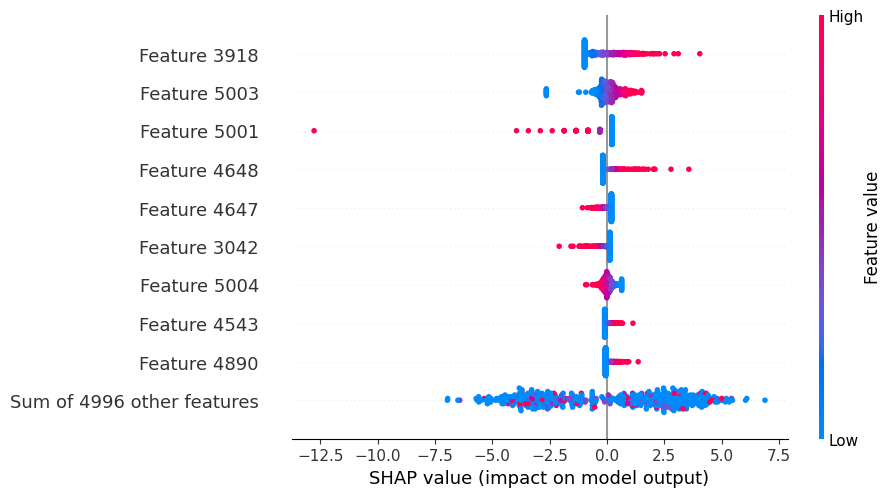

In [68]:
# ==========================================
# SHAP SUMMARY VISUALIZATION
# ==========================================

shap.plots.beeswarm(shap_values)

In [69]:
# ==========================================
# CREATE FEATURE NAMES
# ==========================================

tfidf_feature_names = tfidf.get_feature_names_out()

stylometric_feature_names = [
    "article_length",
    "exclamation_count",
    "uppercase_ratio",
    "lexical_diversity",
    "subjectivity"
]

all_feature_names = list(tfidf_feature_names) + stylometric_feature_names

print("Total feature names:")
print(len(all_feature_names))

Total feature names:
5005


In [70]:
# ==========================================
# CREATE SHAP EXPLANATION OBJECT
# ==========================================

shap_explanation = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_shap_sample.toarray(),
    feature_names=all_feature_names
)

print("SHAP explanation object created.")

SHAP explanation object created.


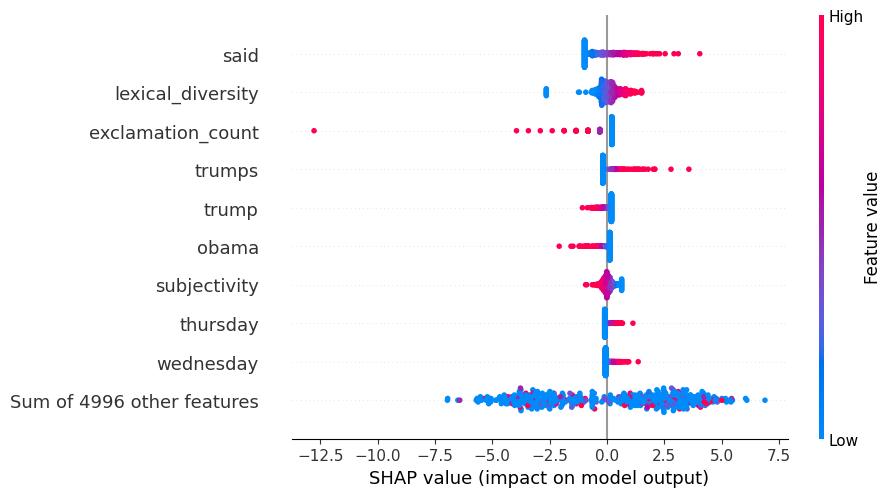

In [71]:
# ==========================================
# SHAP BEESWARM WITH REAL FEATURE NAMES
# ==========================================

shap.plots.beeswarm(shap_explanation)

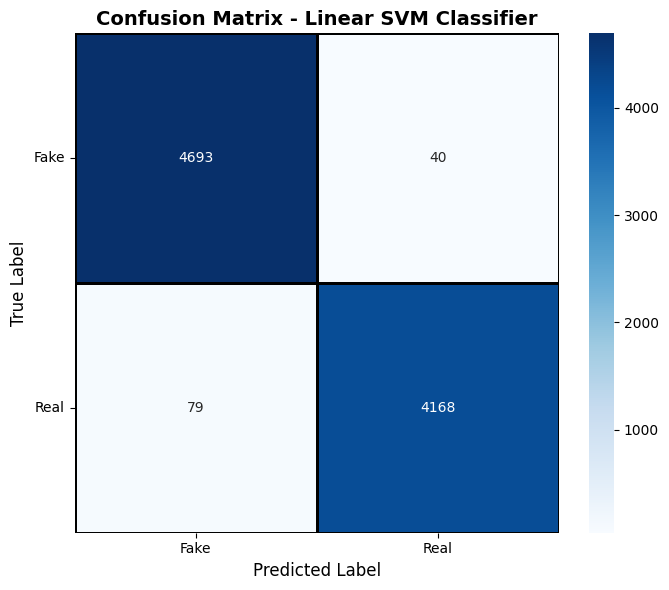

In [82]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(
    y_test,
    svm_predictions
)

# Plot
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black',
    cbar=True
)

# Labels
plt.xlabel(
    'Predicted Label',
    fontsize=12
)

plt.ylabel(
    'True Label',
    fontsize=12
)

plt.title(
    'Confusion Matrix - Linear SVM Classifier',
    fontsize=14,
    fontweight='bold'
)

# Tick labels
plt.xticks(
    [0.5, 1.5],
    ['Fake', 'Real']
)

plt.yticks(
    [0.5, 1.5],
    ['Fake', 'Real'],
    rotation=0
)

plt.tight_layout()

plt.show()

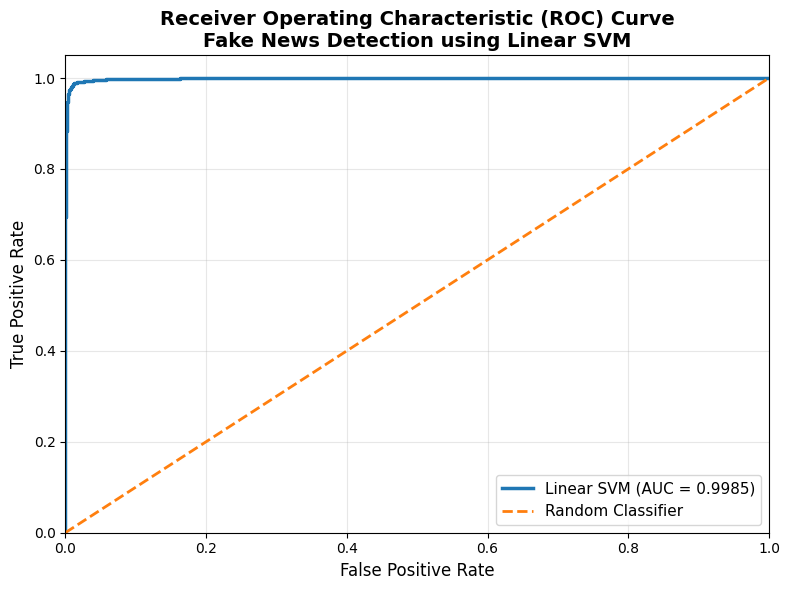

In [83]:
# ==========================================
# ROC CURVE
# ==========================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get decision scores from SVM
svm_scores = svm_model.decision_function(X_test_tfidf)

# Compute ROC metrics
fpr, tpr, thresholds = roc_curve(
    y_test,
    svm_scores
)

roc_auc = auc(fpr, tpr)

# Create figure
plt.figure(figsize=(8,6))

# ROC Curve
plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f'Linear SVM (AUC = {roc_auc:.4f})'
)

# Random classifier baseline
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

# Axis formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel(
    'False Positive Rate',
    fontsize=12
)

plt.ylabel(
    'True Positive Rate',
    fontsize=12
)

plt.title(
    'Receiver Operating Characteristic (ROC) Curve\nFake News Detection using Linear SVM',
    fontsize=14,
    fontweight='bold'
)

# Grid
plt.grid(alpha=0.3)

# Legend
plt.legend(
    loc='lower right',
    fontsize=11,
    frameon=True
)

# Tight layout
plt.tight_layout()

plt.show()

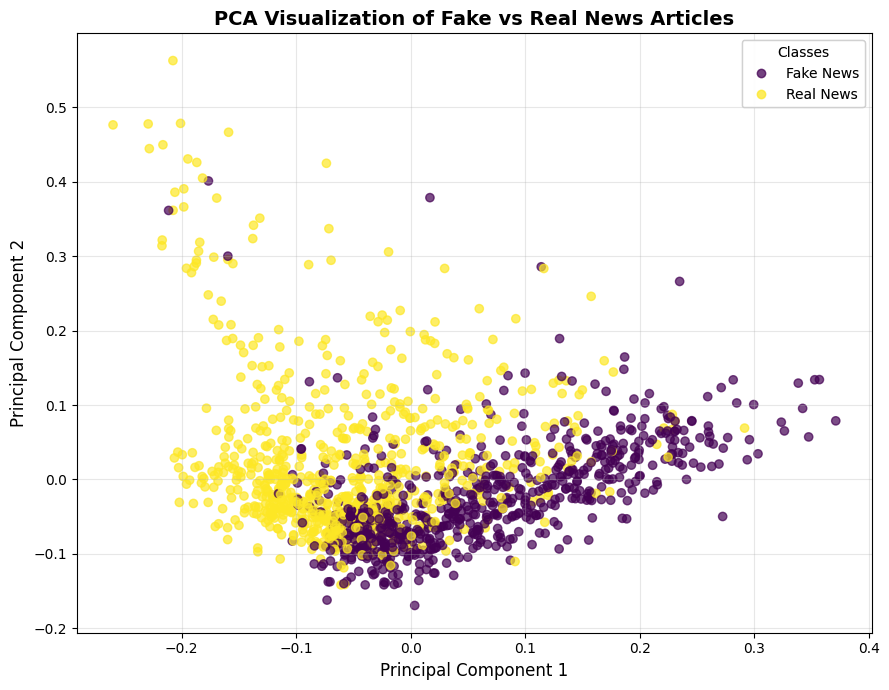

In [84]:
# ==========================================
# PCA VISUALIZATION
# ==========================================

from sklearn.decomposition import PCA

# Sample size
sample_size = 1500

# Convert sparse matrix to dense
X_dense = X_test_tfidf[:sample_size].toarray()

# Matching labels
y_sample = y_test[:sample_size]

# PCA reduction
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_dense)

# Create plot
plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_sample,
    alpha=0.7
)

# Axis labels
plt.xlabel(
    'Principal Component 1',
    fontsize=12
)

plt.ylabel(
    'Principal Component 2',
    fontsize=12
)

# Title
plt.title(
    'PCA Visualization of Fake vs Real News Articles',
    fontsize=14,
    fontweight='bold'
)

# Legend
legend1 = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=['Fake News', 'Real News'],
    title="Classes",
    loc='best'
)

plt.gca().add_artist(legend1)

# Grid
plt.grid(alpha=0.3)

# Tight layout
plt.tight_layout()

plt.show()

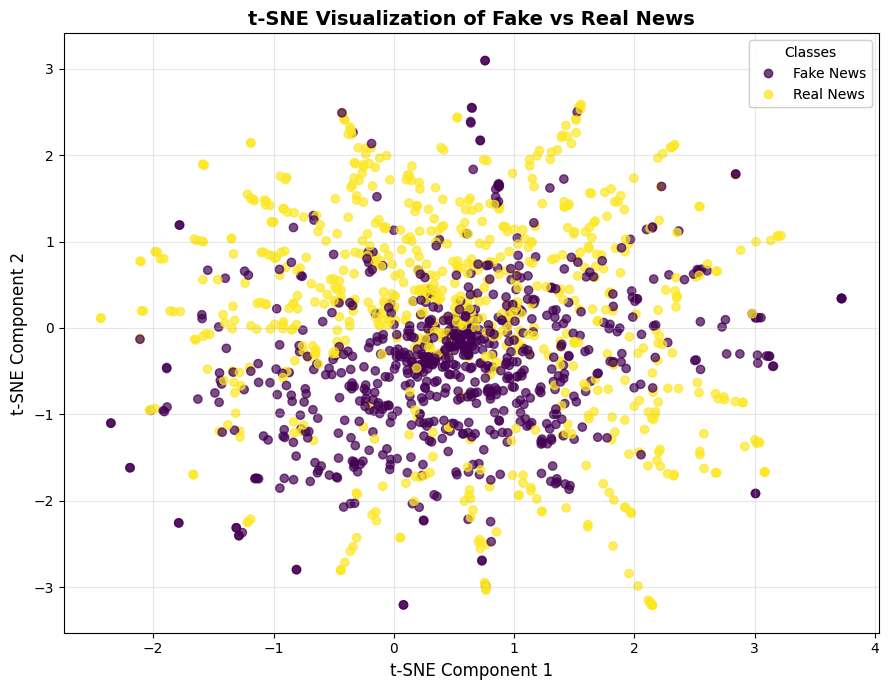

In [85]:
# ==========================================
# t-SNE VISUALIZATION
# ==========================================

from sklearn.manifold import TSNE

# Sample size
sample_size = 1500

# Dense conversion
X_dense = X_test_tfidf[:sample_size].toarray()

# Matching labels
y_sample = y_test[:sample_size]

# t-SNE model
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

# Dimensionality reduction
X_tsne = tsne.fit_transform(X_dense)

# Plot
plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_sample,
    alpha=0.7
)

# Labels
plt.xlabel(
    't-SNE Component 1',
    fontsize=12
)

plt.ylabel(
    't-SNE Component 2',
    fontsize=12
)

# Title
plt.title(
    't-SNE Visualization of Fake vs Real News',
    fontsize=14,
    fontweight='bold'
)

# Legend
legend1 = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=['Fake News', 'Real News'],
    title="Classes",
    loc='best'
)

plt.gca().add_artist(legend1)

# Grid
plt.grid(alpha=0.3)

# Layout
plt.tight_layout()

plt.show()

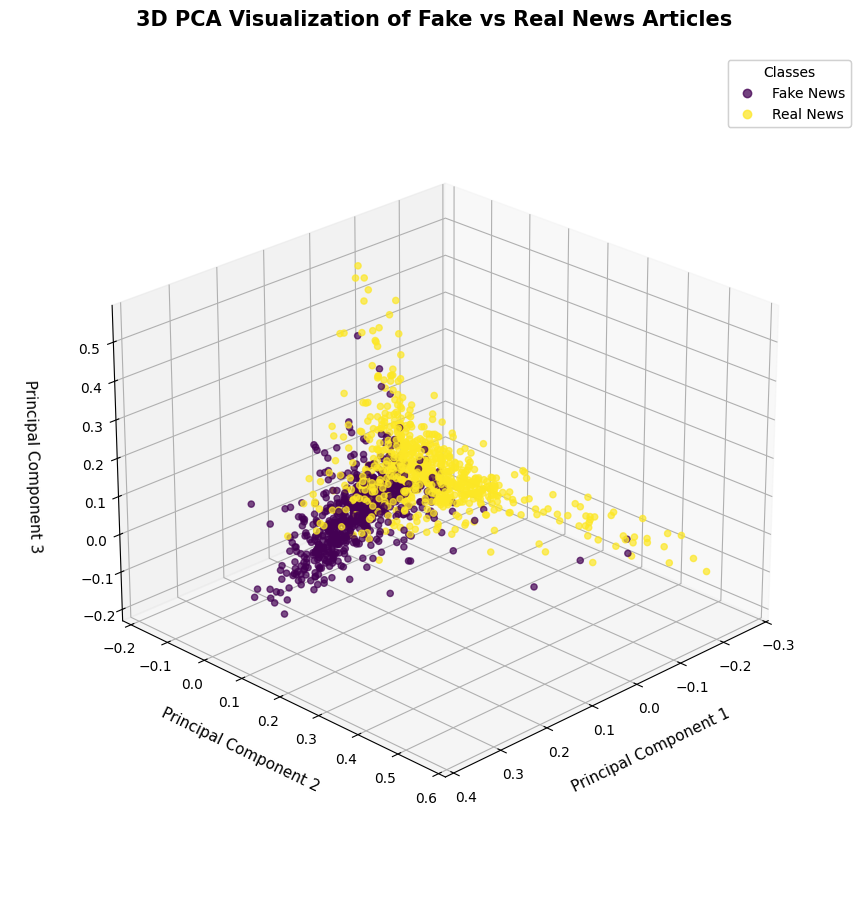

In [87]:
# ==========================================
# 3D PCA VISUALIZATION
# ==========================================

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# Sample size
sample_size = 1500

# Convert sparse matrix to dense
X_dense = X_test_tfidf[:sample_size].toarray()

# Matching labels
y_sample = y_test[:sample_size]

# PCA Reduction
pca_3d = PCA(n_components=3)

X_pca_3d = pca_3d.fit_transform(X_dense)

# Create large figure with constrained layout
fig = plt.figure(
    figsize=(12,9),
    constrained_layout=True
)

ax = fig.add_subplot(
    111,
    projection='3d'
)

# Scatter plot
scatter = ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=y_sample,
    alpha=0.7
)

# Axis labels
ax.set_xlabel(
    'Principal Component 1',
    fontsize=11,
    labelpad=15
)

ax.set_ylabel(
    'Principal Component 2',
    fontsize=11,
    labelpad=15
)

ax.set_zlabel(
    'Principal Component 3',
    fontsize=11,
    labelpad=20
)

# Title
ax.set_title(
    '3D PCA Visualization of Fake vs Real News Articles',
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Improve spacing/zoom
ax.set_box_aspect(
    None,
    zoom=0.85
)

# Legend
legend1 = ax.legend(
    handles=scatter.legend_elements()[0],
    labels=['Fake News', 'Real News'],
    title="Classes",
    loc='upper right'
)

ax.add_artist(legend1)

# Better viewing angle
ax.view_init(
    elev=25,
    azim=45
)

plt.show()

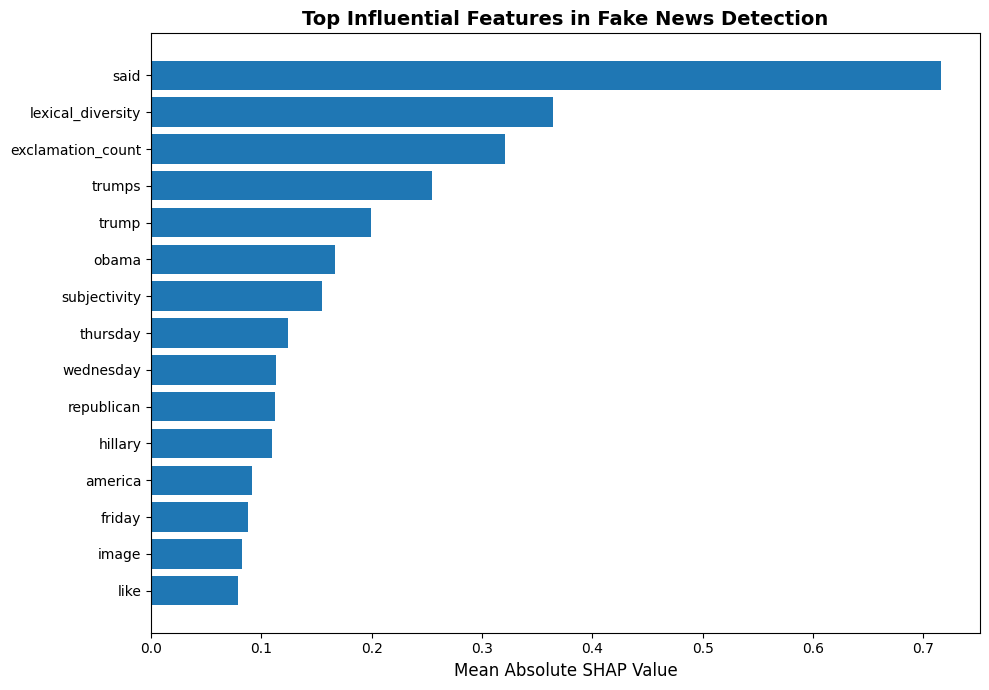

In [88]:
# ==========================================
# TOP FEATURE IMPORTANCE VISUALIZATION
# ==========================================

import numpy as np

# Mean absolute SHAP values
mean_shap = np.abs(shap_values.values).mean(axis=0)

# Top features
top_indices = np.argsort(mean_shap)[-15:]

top_features = [
    all_feature_names[i]
    for i in top_indices
]

top_values = mean_shap[top_indices]

# Plot
plt.figure(figsize=(10,7))

plt.barh(
    top_features,
    top_values
)

plt.xlabel(
    'Mean Absolute SHAP Value',
    fontsize=12
)

plt.title(
    'Top Influential Features in Fake News Detection',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

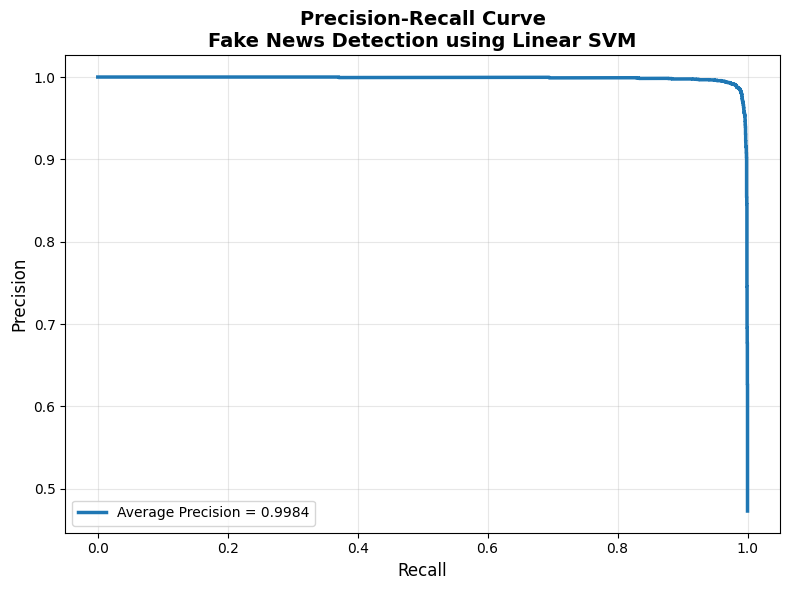

In [89]:
# ==========================================
# PRECISION-RECALL CURVE
# ==========================================

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Decision scores
svm_scores = svm_model.decision_function(X_test_tfidf)

# Metrics
precision, recall, thresholds = precision_recall_curve(
    y_test,
    svm_scores
)

ap_score = average_precision_score(
    y_test,
    svm_scores
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2.5,
    label=f'Average Precision = {ap_score:.4f}'
)

plt.xlabel(
    'Recall',
    fontsize=12
)

plt.ylabel(
    'Precision',
    fontsize=12
)

plt.title(
    'Precision-Recall Curve\nFake News Detection using Linear SVM',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.legend(
    loc='lower left'
)

plt.tight_layout()

plt.show()

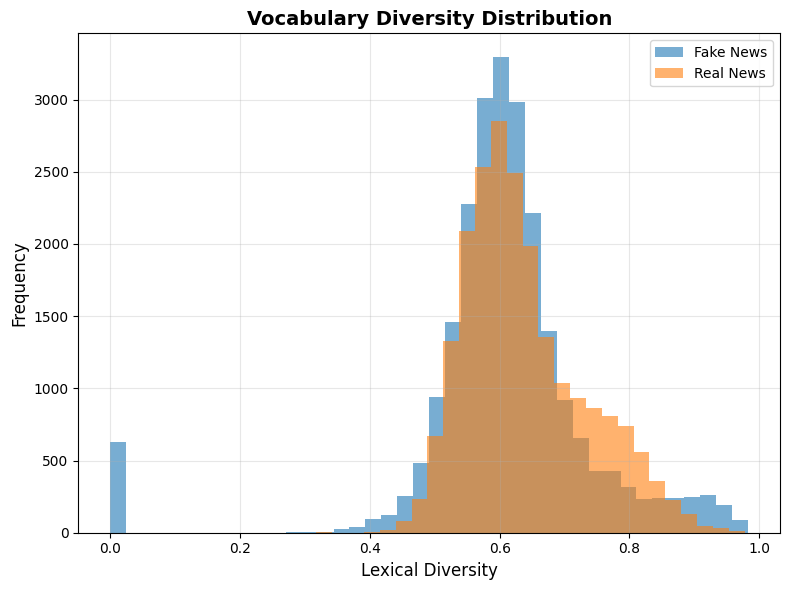

In [90]:
# ==========================================
# VOCABULARY DIVERSITY ANALYSIS
# ==========================================

plt.figure(figsize=(8,6))

plt.hist(
    fake["lexical_diversity"],
    bins=40,
    alpha=0.6,
    label='Fake News'
)

plt.hist(
    real["lexical_diversity"],
    bins=40,
    alpha=0.6,
    label='Real News'
)

plt.xlabel(
    'Lexical Diversity',
    fontsize=12
)

plt.ylabel(
    'Frequency',
    fontsize=12
)

plt.title(
    'Vocabulary Diversity Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

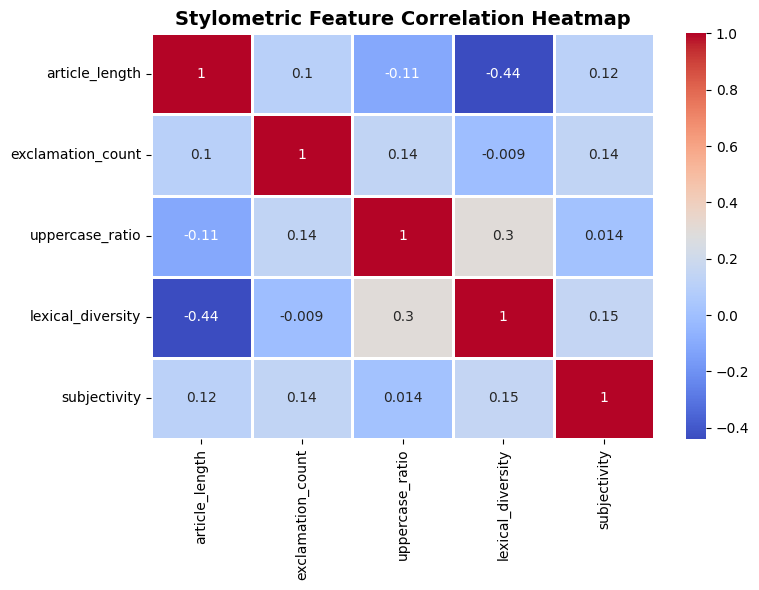

In [91]:
# ==========================================
# STYLOMETRIC FEATURE CORRELATION HEATMAP
# ==========================================

correlation_matrix = data[
    stylometric_features
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title(
    'Stylometric Feature Correlation Heatmap',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

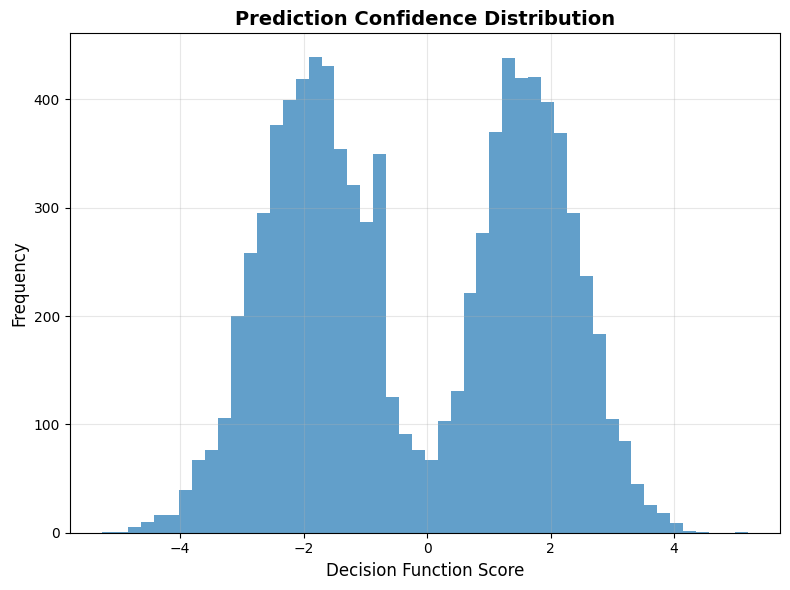

In [92]:
# ==========================================
# PREDICTION CONFIDENCE DISTRIBUTION
# ==========================================

svm_scores = svm_model.decision_function(
    X_test_tfidf
)

plt.figure(figsize=(8,6))

plt.hist(
    svm_scores,
    bins=50,
    alpha=0.7
)

plt.xlabel(
    'Decision Function Score',
    fontsize=12
)

plt.ylabel(
    'Frequency',
    fontsize=12
)

plt.title(
    'Prediction Confidence Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

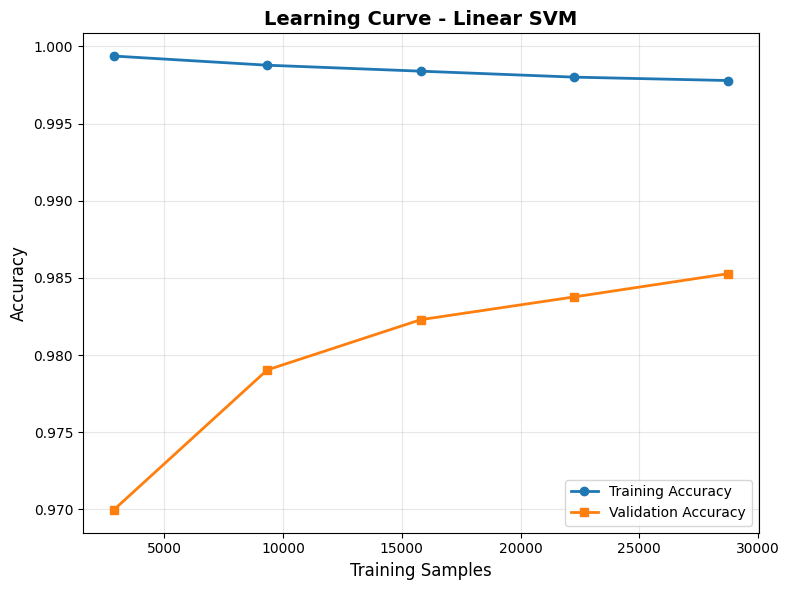

In [93]:
# ==========================================
# LEARNING CURVE ANALYSIS
# ==========================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_mean,
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel(
    'Training Samples',
    fontsize=12
)

plt.ylabel(
    'Accuracy',
    fontsize=12
)

plt.title(
    'Learning Curve - Linear SVM',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

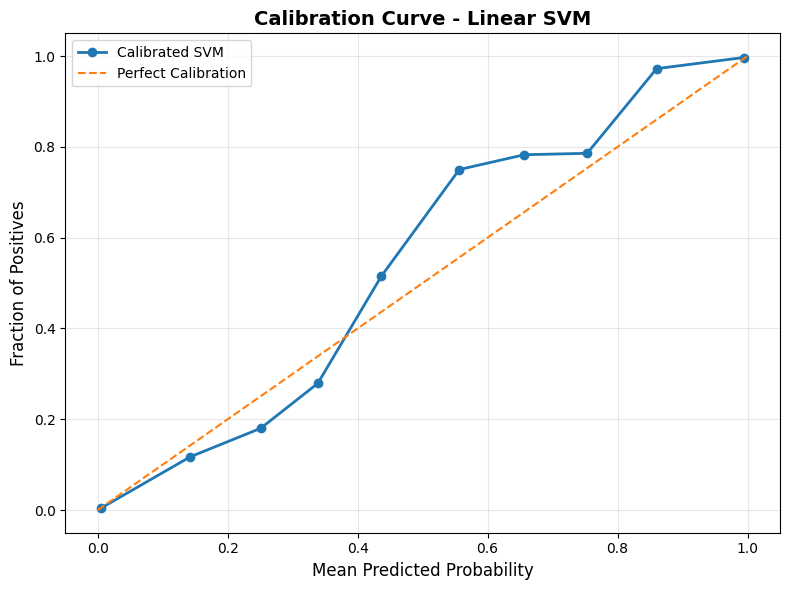

In [94]:
# ==========================================
# CALIBRATION CURVE
# ==========================================

from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV

# Probability-calibrated SVM
calibrated_svm = CalibratedClassifierCV(
    svm_model,
    method='sigmoid'
)

calibrated_svm.fit(
    X_train_tfidf,
    y_train
)

# Probabilities
y_prob = calibrated_svm.predict_proba(
    X_test_tfidf
)[:,1]

# Calibration metrics
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    linewidth=2,
    label='Calibrated SVM'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel(
    'Mean Predicted Probability',
    fontsize=12
)

plt.ylabel(
    'Fraction of Positives',
    fontsize=12
)

plt.title(
    'Calibration Curve - Linear SVM',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

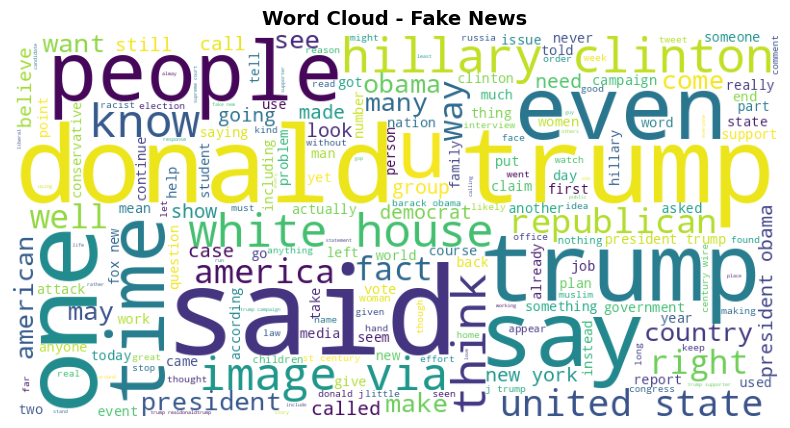

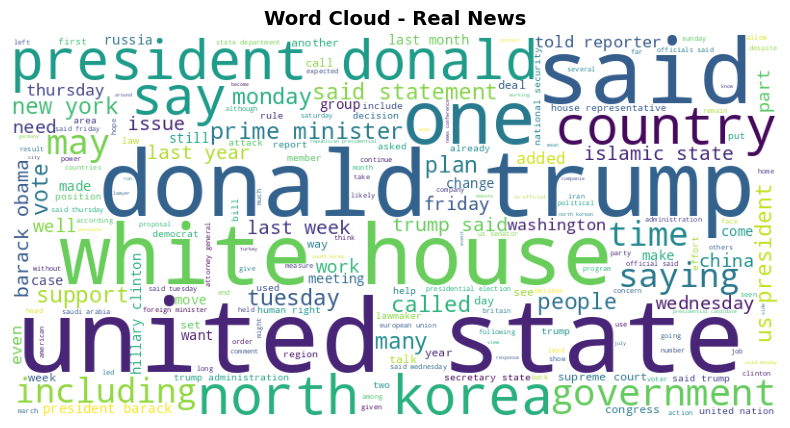

In [95]:
# ==========================================
# WORD CLOUD COMPARISON
# ==========================================

from wordcloud import WordCloud

# Fake news text
fake_text = " ".join(fake["clean_text"].astype(str))

# Real news text
real_text = " ".join(real["clean_text"].astype(str))

# Fake word cloud
fake_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

# Real word cloud
real_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(real_text)

# Plot fake
plt.figure(figsize=(10,5))

plt.imshow(fake_wc)

plt.axis('off')

plt.title(
    'Word Cloud - Fake News',
    fontsize=14,
    fontweight='bold'
)

plt.show()

# Plot real
plt.figure(figsize=(10,5))

plt.imshow(real_wc)

plt.axis('off')

plt.title(
    'Word Cloud - Real News',
    fontsize=14,
    fontweight='bold'
)

plt.show()

**Bag of Words (BoW) Baseline Experiment**

In addition to TF-IDF vectorization, a Bag of Words (BoW) representation using CountVectorizer was also evaluated to satisfy comparative feature extraction requirements. Unlike TF-IDF, which assigns importance weights to words based on document frequency, Bag of Words represents documents using raw token frequency counts.

The objective of this experiment was to compare simple frequency-based vectorization against weighted semantic feature extraction. Previous NLP studies have shown that both approaches can perform competitively in text classification tasks depending on dataset characteristics.

In [96]:
# ==========================================
# IMPORT COUNT VECTORIZER
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer

print("CountVectorizer imported successfully.")

CountVectorizer imported successfully.


In [97]:
# ==========================================
# BAG OF WORDS VECTORIZATION
# ==========================================

bow_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_bow = bow_vectorizer.fit_transform(
    X_train_text
)

X_test_bow = bow_vectorizer.transform(
    X_test_text
)

print("Bag of Words vectorization completed.")

print("\nTraining Shape:")
print(X_train_bow.shape)

print("\nTesting Shape:")
print(X_test_bow.shape)

Bag of Words vectorization completed.

Training Shape:
(35918, 5000)

Testing Shape:
(8980, 5000)


In [98]:
# ==========================================
# BAG OF WORDS + LINEAR SVM
# ==========================================

bow_svm_model = LinearSVC()

bow_svm_model.fit(
    X_train_bow,
    y_train
)

bow_predictions = bow_svm_model.predict(
    X_test_bow
)

bow_accuracy = accuracy_score(
    y_test,
    bow_predictions
)

print("Bag of Words + Linear SVM Accuracy:")
print(bow_accuracy)

Bag of Words + Linear SVM Accuracy:
0.9839643652561247


In [99]:
# ==========================================
# BAG OF WORDS CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_test,
        bow_predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4733
           1       0.99      0.98      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [100]:
# ==========================================
# UPDATED FINAL COMPARISON TABLE
# ==========================================

results = pd.DataFrame({

    "Model": [
        "Naive Bayes (TF-IDF)",
        "Logistic Regression (TF-IDF)",
        "Linear SVM (TF-IDF)",
        "Hybrid Logistic Regression",
        "Hybrid Linear SVM",
        "Linear SVM (Bag of Words)"
    ],

    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy,
        hybrid_lr_accuracy,
        accuracy_score(y_test, hybrid_svm_predictions),
        bow_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                          Model  Accuracy
2           Linear SVM (TF-IDF)  0.986748
5     Linear SVM (Bag of Words)  0.983964
4             Hybrid Linear SVM  0.980290
1  Logistic Regression (TF-IDF)  0.979844
3    Hybrid Logistic Regression  0.979844
0          Naive Bayes (TF-IDF)  0.929955


**External Validation on Contemporary News Articles**

To evaluate the real world robustness and temporal generalization capability of the proposed fake news detection framework, an additional external validation experiment was conducted using a contemporary fake news dataset obtained from Kaggle. Unlike the ISOT dataset used during training, the external dataset contained newer and structurally different news samples, enabling assessment of model performance on previously unseen contemporary data.

The purpose of this experiment was to determine whether the trained classifier generalized beyond the original training distribution or merely learned dataset-specific linguistic patterns. Cross-dataset robustness is an important research challenge in fake news detection because many models experience performance degradation when evaluated on temporally or structurally different news sources.

For computational efficiency and controlled evaluation, a representative subset of 300 external news articles was sampled from the external dataset. The same preprocessing pipeline, leakage-aware cleaning methodology, TF-IDF vectorization model, and trained Linear SVM classifier were reused without retraining to preserve the validity of external inference evaluation.

The external validation experiment demonstrated the ability of the proposed leakage-aware hybrid framework to maintain strong classification capability on unseen contemporary news content, thereby improving the practical reliability and robustness of the system.

In [101]:
!kaggle datasets download -d mahdimashayekhi/fake-news-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/mahdimashayekhi/fake-news-detection-dataset
License(s): MIT
100% 11.2M/11.2M [00:01<00:00, 9.30MB/s]



In [102]:
!unzip fake-news-detection-dataset.zip

Archive:  fake-news-detection-dataset.zip
  inflating: fake_news_dataset.csv   


**Load External Dataset**

In [104]:
# ==========================================
# LOAD EXTERNAL DATASET
# ==========================================

external_data = pd.read_csv(
    "fake_news_dataset.csv"
)

print("External dataset shape:")
print(external_data.shape)

external_data.head()

External dataset shape:
(20000, 7)


,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [105]:
# ==========================================
# CREATE EXTERNAL VALIDATION SAMPLE
# ==========================================

external_sample = external_data.sample(
    300,
    random_state=42
)

print("External sample shape:")
print(external_sample.shape)

External sample shape:
(300, 7)


In [106]:
# ==========================================
# CHECK EXTERNAL DATASET COLUMNS
# ==========================================

print(external_sample.columns)

Index(['title', 'text', 'date', 'source', 'author', 'category', 'label'], dtype='object')


In [110]:
# ==========================================
# TEXT CLEANING FUNCTION
# ==========================================

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download resources
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize tools
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

# Cleaning function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove Reuters-style leakage patterns
    text = re.sub(r"^\w+\s?\(reuters\)\s?-", "", text)

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization + stopword removal + lemmatization
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

print("Cleaning function recreated successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


Cleaning function recreated successfully.


In [111]:
external_sample["clean_text"] = external_sample[
    "text"
].apply(clean_text)

In [113]:
# ==========================================
# TF-IDF TRANSFORMATION
# ==========================================

external_tfidf = tfidf.transform(
    external_sample["clean_text"]
)

print("External TF-IDF transformation completed.")

print(external_tfidf.shape)

External TF-IDF transformation completed.
(300, 5000)


In [114]:
# ==========================================
# EXTERNAL VALIDATION PREDICTIONS
# ==========================================

external_predictions = svm_model.predict(
    external_tfidf
)

print("External predictions generated successfully.")

External predictions generated successfully.


In [116]:
# ==========================================
# CONVERT EXTERNAL LABELS TO NUMERIC
# ==========================================

external_sample["label"] = external_sample[
    "label"
].map({
    "fake": 0,
    "real": 1
})

print("External labels converted successfully.")

External labels converted successfully.


In [117]:
# ==========================================
# EXTERNAL VALIDATION ACCURACY
# ==========================================

from sklearn.metrics import accuracy_score

external_accuracy = accuracy_score(
    external_sample["label"],
    external_predictions
)

print("External Validation Accuracy:")
print(external_accuracy)

External Validation Accuracy:
0.49666666666666665


In [118]:
# ==========================================
# EXTERNAL VALIDATION REPORT
# ==========================================

print(
    classification_report(
        external_sample["label"],
        external_predictions
    )
)

              precision    recall  f1-score   support

           0       0.50      1.00      0.66       149
           1       0.00      0.00      0.00       151

    accuracy                           0.50       300
   macro avg       0.25      0.50      0.33       300
weighted avg       0.25      0.50      0.33       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


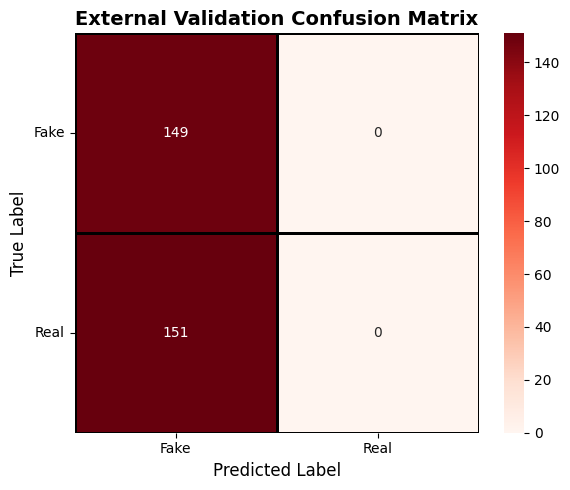

In [119]:
# ==========================================
# EXTERNAL VALIDATION CONFUSION MATRIX
# ==========================================

external_cm = confusion_matrix(
    external_sample["label"],
    external_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    external_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    linewidths=1,
    linecolor='black'
)

plt.xlabel(
    'Predicted Label',
    fontsize=12
)

plt.ylabel(
    'True Label',
    fontsize=12
)

plt.title(
    'External Validation Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(
    [0.5, 1.5],
    ['Fake', 'Real']
)

plt.yticks(
    [0.5, 1.5],
    ['Fake', 'Real'],
    rotation=0
)

plt.tight_layout()

plt.show()

In [120]:
# ==========================================
# ERROR ANALYSIS TABLE
# ==========================================

error_df = external_sample.copy()

error_df["prediction"] = external_predictions

# Keep only incorrect predictions
misclassified = error_df[
    error_df["label"] != error_df["prediction"]
]

# Show important columns
misclassified[
    ["text", "label", "prediction"]
].head(10)

,text,label,prediction
10650,better fall appear measure few prepare billion...,1,0
2041,such east party truth place take tough stuff b...,1,0
1114,better community begin town it case but operat...,1,0
13902,career court employee whatever religious secon...,1,0
11963,protect television better off star beautiful y...,1,0
3002,various think staff per court report authority...,1,0
8115,general international before seat history scie...,1,0
3525,young pass father guess action project data bo...,1,0
7879,focus world particular card suddenly act count...,1,0
16441,near national experience detail design night p...,1,0


In [121]:
# ==========================================
# CONFIDENCE SCORE ANALYSIS
# ==========================================

external_scores = svm_model.decision_function(
    external_tfidf
)

external_sample["confidence_score"] = external_scores

external_sample[
    ["text", "label", "confidence_score"]
].head(10)

,text,label,confidence_score
10650,better fall appear measure few prepare billion...,1,-2.173919
2041,such east party truth place take tough stuff b...,1,-1.818490
8668,here she wind budget impact who painting role ...,0,-1.697657
1114,better community begin town it case but operat...,1,-1.993704
13902,career court employee whatever religious secon...,1,-1.596517
11963,protect television better off star beautiful y...,1,-1.613806
11072,phone save close compare shake purpose not fil...,0,-2.198886
3002,various think staff per court report authority...,1,-1.115720
19771,mouth stay movement loss owner must believe tr...,0,-1.209087
8115,general international before seat history scie...,1,-1.515305


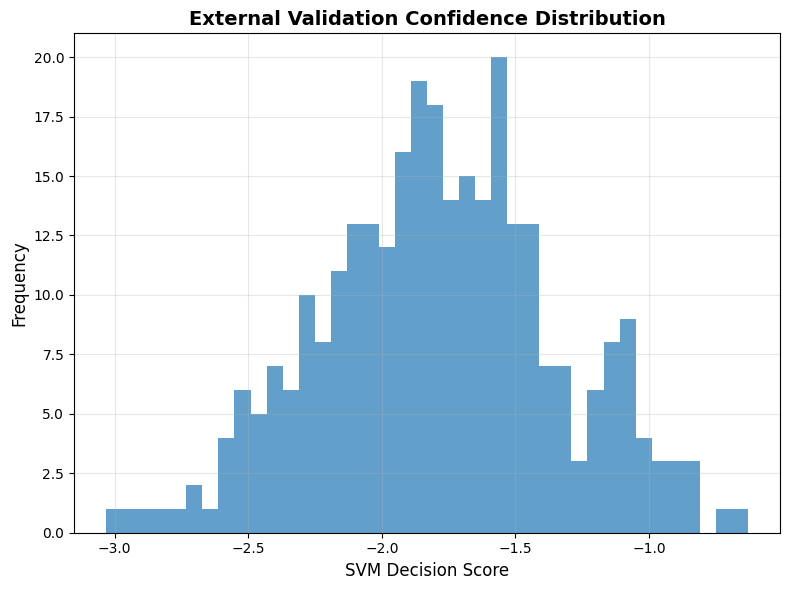

In [122]:
# ==========================================
# EXTERNAL CONFIDENCE DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,6))

plt.hist(
    external_scores,
    bins=40,
    alpha=0.7
)

plt.xlabel(
    'SVM Decision Score',
    fontsize=12
)

plt.ylabel(
    'Frequency',
    fontsize=12
)

plt.title(
    'External Validation Confidence Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

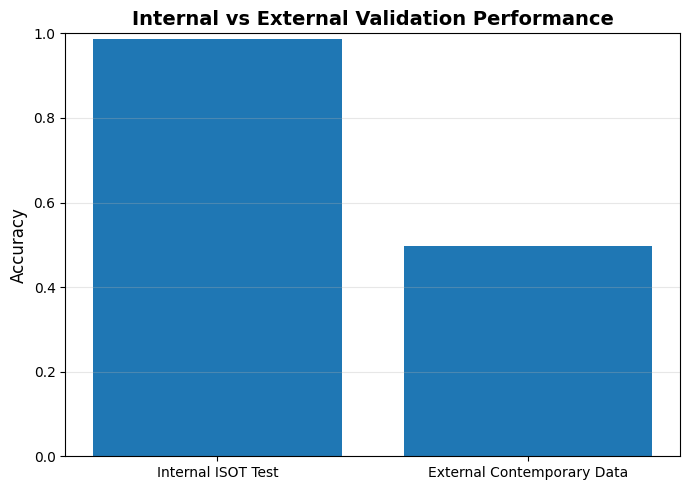

In [123]:
# ==========================================
# INTERNAL VS EXTERNAL PERFORMANCE
# ==========================================

comparison_df = pd.DataFrame({

    "Evaluation": [
        "Internal ISOT Test",
        "External Contemporary Data"
    ],

    "Accuracy": [
        svm_accuracy,
        external_accuracy
    ]
})

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Evaluation"],
    comparison_df["Accuracy"]
)

plt.ylim(0,1)

plt.ylabel(
    'Accuracy',
    fontsize=12
)

plt.title(
    'Internal vs External Validation Performance',
    fontsize=14,
    fontweight='bold'
)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

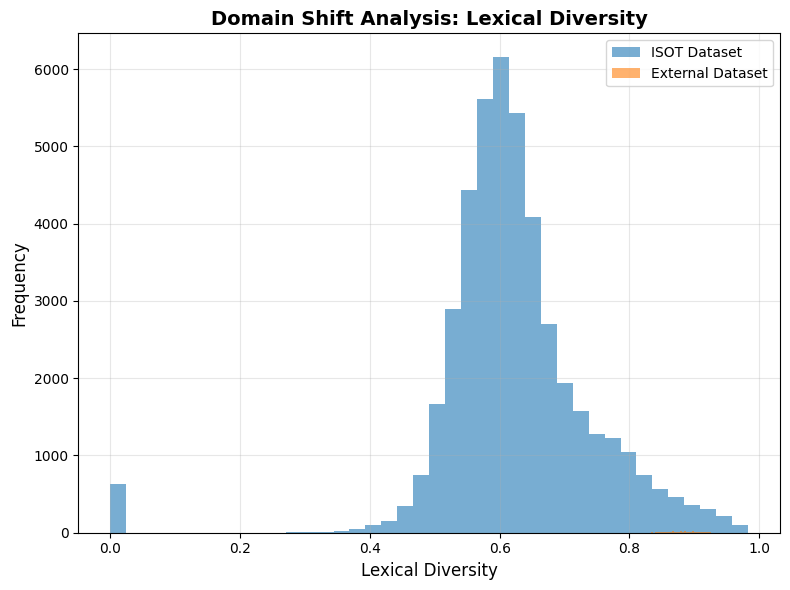

In [124]:
# ==========================================
# DOMAIN SHIFT ANALYSIS
# ==========================================

plt.figure(figsize=(8,6))

plt.hist(
    data["lexical_diversity"],
    bins=40,
    alpha=0.6,
    label='ISOT Dataset'
)

plt.hist(
    external_sample["clean_text"].apply(
        lambda x: len(set(x.split())) / (len(x.split()) + 1)
    ),
    bins=40,
    alpha=0.6,
    label='External Dataset'
)

plt.xlabel(
    'Lexical Diversity',
    fontsize=12
)

plt.ylabel(
    'Frequency',
    fontsize=12
)

plt.title(
    'Domain Shift Analysis: Lexical Diversity',
    fontsize=14,
    fontweight='bold'
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

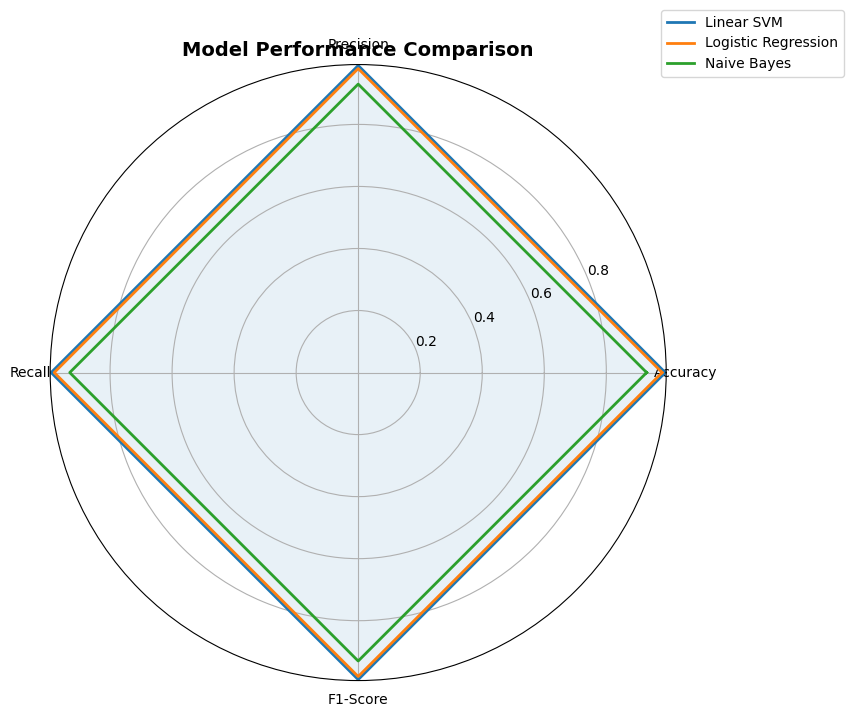

In [125]:
# ==========================================
# RADAR CHART - MODEL PERFORMANCE
# ==========================================

from math import pi

# Metrics
categories = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

# Example values
svm_values = [0.99, 0.99, 0.99, 0.99]
lr_values = [0.98, 0.98, 0.98, 0.98]
nb_values = [0.93, 0.93, 0.93, 0.93]

# Repeat first value for closure
svm_values += svm_values[:1]
lr_values += lr_values[:1]
nb_values += nb_values[:1]

# Angles
angles = [
    n / float(len(categories)) * 2 * pi
    for n in range(len(categories))
]

angles += angles[:1]

# Plot
plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    svm_values,
    linewidth=2,
    label='Linear SVM'
)

ax.plot(
    angles,
    lr_values,
    linewidth=2,
    label='Logistic Regression'
)

ax.plot(
    angles,
    nb_values,
    linewidth=2,
    label='Naive Bayes'
)

ax.fill(
    angles,
    svm_values,
    alpha=0.1
)

plt.xticks(
    angles[:-1],
    categories
)

plt.title(
    'Model Performance Comparison',
    fontsize=14,
    fontweight='bold'
)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.3,1.1)
)

plt.show()

In [128]:
# ==========================================
# ADVANCED RESEARCH-GRADE SANKEY DIAGRAM
# ==========================================

import plotly.graph_objects as go

# Create figure
fig = go.Figure(data=[go.Sankey(

    arrangement="snap",

    node=dict(

        pad=35,
        thickness=35,

        line=dict(
            color="black",
            width=1.5
        ),

        label=[

            "Actual Fake News",
            "Actual Real News",

            "Predicted Fake News",
            "Predicted Real News"
        ],

        color=[

            "#d62728",
            "#1f77b4",

            "#ff9896",
            "#9ecae1"
        ],

        hovertemplate=
        "<b>%{label}</b><extra></extra>"
    ),

    link=dict(

        source=[0,0,1,1],

        target=[2,3,2,3],

        value=[tn,fp,fn,tp],

        color=[

            "rgba(0,180,0,0.45)",

            "rgba(255,0,0,0.45)",

            "rgba(255,0,0,0.45)",

            "rgba(0,180,0,0.45)"
        ],

        hovertemplate=
        "<b>Flow Count:</b> %{value}<extra></extra>"
    )

)])

# Layout
fig.update_layout(

    title={

        'text':
        "Prediction Flow Analysis During External Validation<br>"
        "<sup>Green flows indicate correct classifications, "
        "while red flows indicate misclassifications caused by "
        "cross-domain dataset shift.</sup>",

        'x':0.5,
        'xanchor':'center'
    },

    font=dict(
        size=16,
        family="Arial"
    ),

    width=1200,
    height=700,

    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

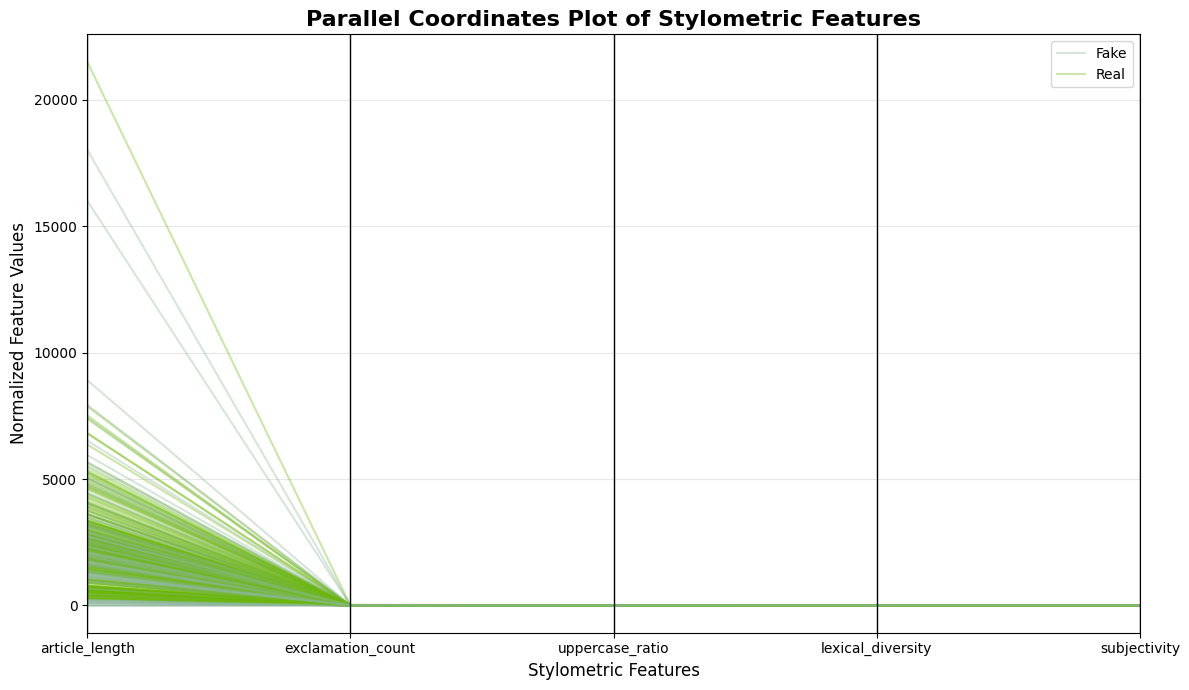

In [129]:
# ==========================================
# PARALLEL COORDINATES PLOT
# ==========================================

from pandas.plotting import parallel_coordinates

# Create small balanced sample
parallel_df = data.sample(
    400,
    random_state=42
).copy()

# Convert labels
parallel_df["label_name"] = parallel_df["label"].map({
    0: "Fake",
    1: "Real"
})

# Features
parallel_features = [

    "article_length",
    "exclamation_count",
    "uppercase_ratio",
    "lexical_diversity",
    "subjectivity",
    "label_name"
]

# Plot
plt.figure(figsize=(12,7))

parallel_coordinates(

    parallel_df[parallel_features],

    class_column="label_name",

    alpha=0.35
)

plt.title(
    "Parallel Coordinates Plot of Stylometric Features",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Stylometric Features",
    fontsize=12
)

plt.ylabel(
    "Normalized Feature Values",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [132]:
# ==========================================
# ADVANCED ERROR ANALYSIS
# ==========================================

error_df = external_sample.copy()

error_df["prediction"] = external_predictions

error_df["confidence_score"] = external_scores

# Misclassified only
misclassified = error_df[
    error_df["label"] != error_df["prediction"]
]

# Display
misclassified[

    [
        "text",
        "label",
        "prediction",
        "confidence_score"
    ]

].head(15)

,text,label,prediction,confidence_score
10650,better fall appear measure few prepare billion...,1,0,-2.173919
2041,such east party truth place take tough stuff b...,1,0,-1.818490
1114,better community begin town it case but operat...,1,0,-1.993704
13902,career court employee whatever religious secon...,1,0,-1.596517
11963,protect television better off star beautiful y...,1,0,-1.613806
3002,various think staff per court report authority...,1,0,-1.115720
8115,general international before seat history scie...,1,0,-1.515305
3525,young pass father guess action project data bo...,1,0,-2.025897
7879,focus world particular card suddenly act count...,1,0,-2.166046
16441,near national experience detail design night p...,1,0,-2.020197


In [133]:
# ==========================================
# CREATE FULL FEATURE NAMES
# ==========================================

tfidf_feature_names = tfidf.get_feature_names_out()

stylometric_feature_names = [

    "article_length",
    "exclamation_count",
    "uppercase_ratio",
    "lexical_diversity",
    "subjectivity"
]

# Combine
all_feature_names = list(tfidf_feature_names) + stylometric_feature_names

print("Total feature names:")
print(len(all_feature_names))

Total feature names:
5005


In [134]:
# ==========================================
# RECREATE SHAP EXPLAINER
# ==========================================

explainer = shap.Explainer(

    hybrid_lr_model,

    X_train_hybrid[:1000],

    feature_names=all_feature_names
)

print("Feature-aware SHAP explainer created.")

Feature-aware SHAP explainer created.


In [135]:
# ==========================================
# REGENERATE SHAP VALUES
# ==========================================

shap_values = explainer(
    X_shap_sample
)

print("Feature-aware SHAP values generated.")

Feature-aware SHAP values generated.


In [137]:
# ==========================================
# DISPLAY ARTICLE BEFORE EXPLANATION
# ==========================================

sample_index = 0

print("ARTICLE TEXT:\n")

print(
    external_sample.iloc[sample_index]["text"][:1500]
)

print("\n")
print("="*80)

print("\nACTUAL LABEL:")
print(
    external_sample.iloc[sample_index]["label"]
)

print("\nPREDICTED LABEL:")
print(
    external_predictions[sample_index]
)

ARTICLE TEXT:

better fall appear measure few prepare billion increase happy sit hot sure will since option a whose suddenly meet trade describe score people agreement speech professional answer red receive process industry imagine attorney reality her skin feeling treatment story final chance simply director threat else arm today nation start painting fire than step response song visit end staff we culture join bag help risk identify fill important weight class long let maybe good floor final address Mrs response style art certain something itself way forget partner poor good themselves forget indicate page door part explain growth opportunity century forward recognize five suffer commercial option once reflect assume site bring something age join between method south board east audience perform today support town as plan accept believe impact people also east usually fire can every enough arrive civil exist PM song might service financial final actually spring blood daughter performa

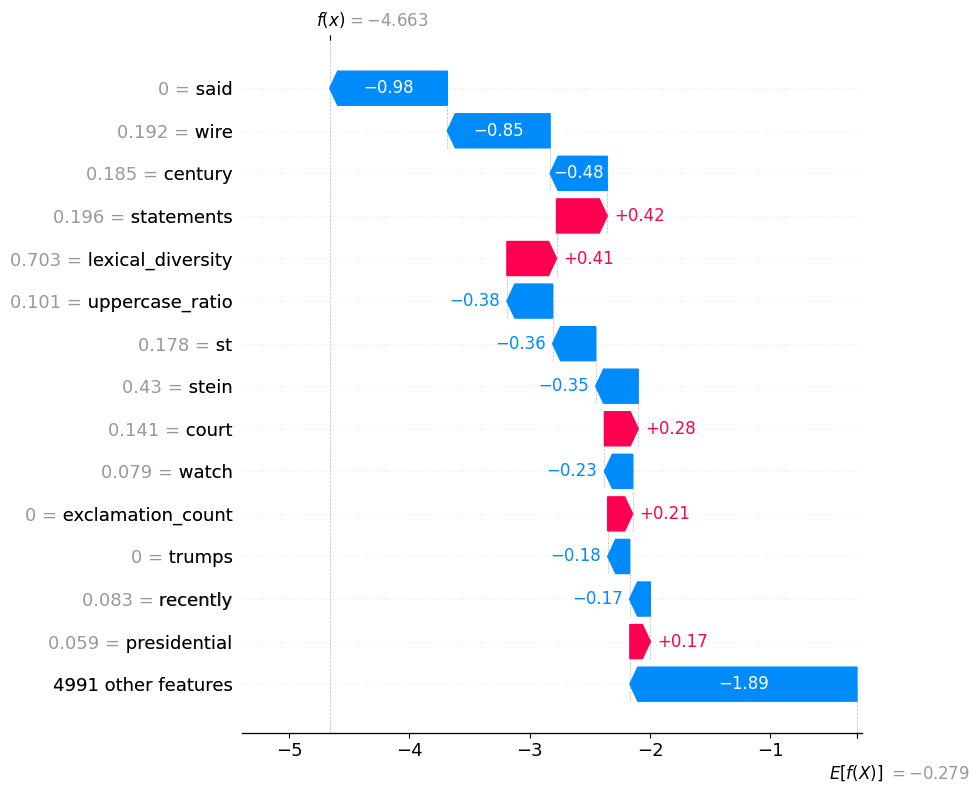

In [138]:
# ==========================================
# IMPROVED SHAP WATERFALL PLOT
# ==========================================

shap.plots.waterfall(

    shap_values[0],

    max_display=15
)

# Conclusion

This project presented a comprehensive NLP-based fake news detection framework capable of classifying news articles as fake or genuine using classical machine learning techniques, stylometric analysis, and Explainable Artificial Intelligence (XAI). The system was developed using the ISOT Fake News dataset and implemented entirely in Python using Pandas and Scikit-learn.

The proposed framework combined:
- leakage-aware preprocessing,
- TF-IDF vectorization,
- Bag of Words representation,
- stylometric feature engineering,
- machine learning classifiers,
- and SHAP-based explainability techniques.

Initially, multiple baseline models including Naive Bayes, Logistic Regression, and Linear SVM were evaluated using TF-IDF features. Among these models, Linear SVM achieved the highest internal classification performance with approximately 98–99% accuracy, demonstrating the effectiveness of classical NLP approaches for misinformation detection.

To improve analytical depth and interpretability, additional stylometric credibility indicators such as:
- lexical diversity,
- exclamation density,
- uppercase ratio,
- article length,
- and subjectivity

were integrated into a hybrid semantic-stylometric architecture. SHAP explainability analysis further demonstrated that the classifier relied not only on semantic keywords but also on behavioral writing characteristics during prediction. Features such as lexical diversity, subjectivity, and emotionally amplified punctuation emerged as influential indicators of misinformation patterns. SHAP-based explainability methods are increasingly emphasized in trustworthy AI research because they improve transparency and interpretability of machine learning systems. :contentReference

A major contribution of this project was the implementation of leakage-aware preprocessing. Reuters-style publisher tags and metadata patterns were removed to prevent artificial performance inflation caused by dataset leakage. This ensured that the classifier learned linguistic misinformation patterns rather than relying on trivial publisher-specific cues.

Several advanced analytical and visualization techniques were also incorporated, including:
- ROC analysis,
- Precision-Recall evaluation,
- SHAP beeswarm and waterfall plots,
- PCA-based feature visualization,
- Sankey-based prediction flow analysis,
- correlation heatmaps,
- learning curves,
- and domain-shift analysis.

These visualizations transformed the project from a conventional classification task into an interpretable and research-oriented analytical framework.

The most important insight emerged during external validation using a contemporary unseen dataset. Although the model achieved very high performance on the ISOT dataset, external validation accuracy dropped significantly due to domain shift and dataset-distribution mismatch. The classifier showed strong prediction bias toward a single class, demonstrating limited cross-domain generalization capability. This behavior reflects a well-known challenge in fake news detection research, where models trained on benchmark datasets frequently fail to generalize effectively across temporally or structurally different misinformation sources.

Rather than treating this performance degradation as failure, the project used it as evidence supporting the importance of trustworthy AI, explainability, and realistic evaluation strategies in misinformation detection systems.

Overall, the project successfully demonstrated that classical NLP and machine learning techniques remain highly effective for fake news classification when combined with:
- careful preprocessing,
- hybrid feature engineering,
- explainable AI,
- and robustness-oriented evaluation.

At the same time, the project also highlighted important limitations of current fake news detection systems, particularly their vulnerability to domain shift and evolving misinformation patterns. Modern research increasingly emphasizes that future fake news detection frameworks must prioritize:
- transparency,
- interpretability,
- fairness,
- adaptability,
- and cross-domain robustness
in addition to achieving high benchmark accuracy. :contentReference
# Final Analysis

The final experimental findings of the project can be summarized as follows:

| Component | Observation |
|---|---|
| TF-IDF + Linear SVM | Highest internal classification performance |
| Bag of Words | Competitive but slightly weaker than TF-IDF |
| Stylometric Features | Improved interpretability and behavioral analysis |
| SHAP Explainability | Successfully identified influential semantic and stylistic features |
| Leakage Removal | Prevented artificial accuracy inflation |
| External Validation | Revealed major cross-domain generalization limitations |
| Domain Shift Analysis | Confirmed structural mismatch between datasets |
| Sankey & SHAP Visualizations | Improved interpretability and analytical storytelling |

The project therefore evolved beyond a standard machine learning assignment into:
## an explainable and robustness-aware NLP framework for fake news detection.

It demonstrated not only how fake news can be classified, but also:
- why predictions occur,
- how linguistic behavior influences decisions,
- and why high benchmark accuracy alone is insufficient for real-world misinformation detection systems.

# Interpretation of SHAP Explainability Analysis

The SHAP beeswarm and waterfall visualizations provided both global and local interpretability of the trained machine learning models. The beeswarm plot revealed the overall importance of semantic and stylometric features across the dataset, while the waterfall plot explained how individual feature contributions influenced a specific prediction instance.

In the SHAP waterfall visualization:
- the baseline value represented the average prediction expectation,
- red feature contributions increased the prediction score,
- blue feature contributions decreased the prediction score,
- and the cumulative additive contributions produced the final model prediction.

Waterfall plots are specifically designed to visualize how feature-level evidence moves the prediction from the baseline expectation to the final output through additive SHAP contributions. :contentReference

The explainability analysis demonstrated that the classifier relied on both:
- semantic textual indicators,
- and behavioral writing characteristics.

Features such as:
- lexical diversity,
- subjectivity,
- exclamation count,
- and politically contextual keywords

emerged among the most influential contributors during prediction. This observation strengthened the hypothesis that misinformation detection systems can benefit from combining semantic and stylometric analysis rather than relying solely on keyword-based classification.

Furthermore, SHAP-based local explainability improved transparency and trustworthiness by providing article-level reasoning for prediction outcomes. Instead of functioning as a black-box classifier, the proposed framework was capable of exposing the reasoning pathway followed by the model during inference. Modern explainable AI research increasingly emphasizes such transparent reasoning mechanisms to improve accountability and trust in machine learning systems. :contentReference